In [1]:
#!pip install --prefix (sys.prefix) pandas tensorflow scikit-learn matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
np.random.seed(1)

In [4]:
# load data
df = pd.read_csv('D:\\paper\\C\\data\\5\\6data.csv')
requests = pd.DataFrame(data=df,columns=['Requests'])

requests.ffill(inplace=True)
requests["Requests"] = requests["Requests"].astype(float).astype(int)

In [5]:
#Review loaded data
# print(requests.dtypes)
# requests.head()
print(requests)

    Requests
0        826
1        130
2        101
3         72
4         37
5         56
6         75
7       1120
8       2051
9       2983
10      2526
11      1890
12      1255
13       126
14        92
15        59
16        50
17        87
18       123
19      1336
20      2101
21      2865
22      2696
23      2076
24      1457
25       126
26        79
27        33
28        69
29        96
30       123
31      1657
32      2495
33      3334
34      3334
35      1941
36      1120
37       186
38        41
39        48
40        55
41        86
42       713
43      1340
44      3260
45      3301
46      3342
47      1529
48       817
49       105
50        74
51        43
52        72
53        93
54       114
55       590
56      1066
57      3018
58      3058
59      1967


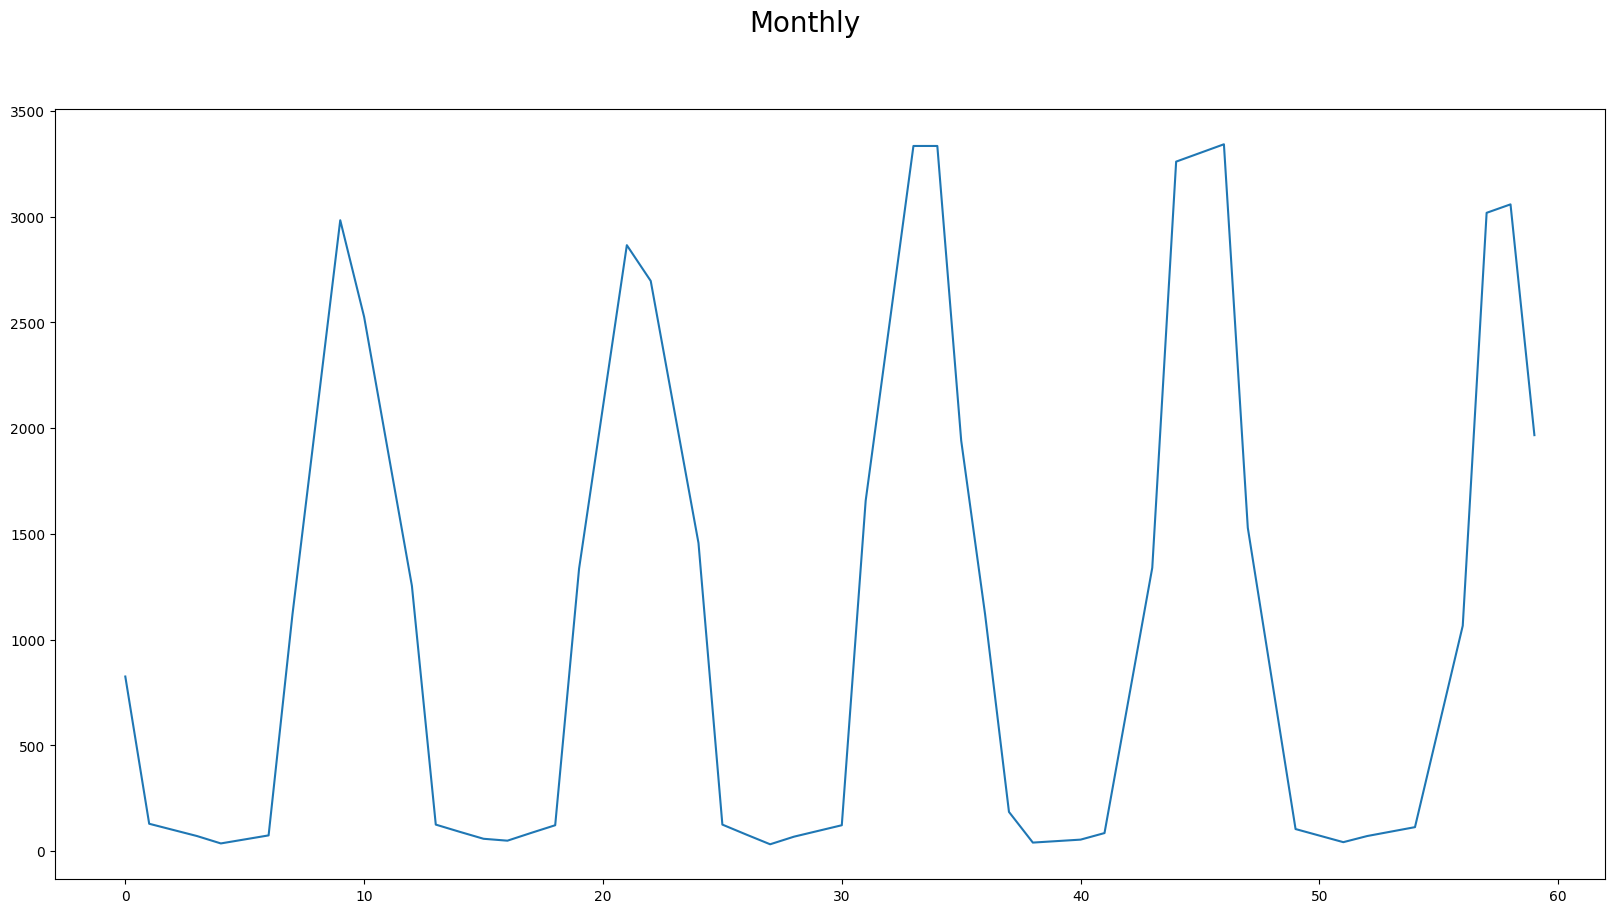

In [6]:
#plot the data loaded to visualze trends
#daily
#plt.figure(figsize=(20,5)).suptitle("Daily", fontsize=20)
#plt.plot(requests["Requests"])
#plt.show()

#weekly
#plt.figure(figsize=(20,5)).suptitle("weekly", fontsize=20)
#plt.plot(requests["Requests"])
#plt.show()

#monthly
plt.figure(figsize=(20,10)).suptitle("Monthly", fontsize=20)
plt.plot(requests["Requests"])
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

#scale the data
print("Request Range before scaling : " ,
          min(requests.Requests),
          max(requests.Requests))

scaler = StandardScaler()
scaled_requests=scaler.fit_transform(requests)
print("Request Range after scaling : " ,
          min(scaled_requests),
          max(scaled_requests))

#training data has to be sequencial
train_size = 30

#number of samples to lookback for each shape
lookback = 4

#separate training and test data
train_requests = scaled_requests[0:train_size,:]

#add an aditional week for lookback
test_requests = scaled_requests[train_size-lookback:,:]

print("\n shaped of Train, Test : ",
      train_requests.shape, test_requests.shape)

Request Range before scaling :  33 3342
Request Range after scaling :  [-0.90900497] [1.9315372]

 shaped of Train, Test :  (30, 1) (34, 1)


In [8]:
#build lstm model

#prepare RNN Dataset
def create_rnn_dataset(data, lookback=1):
    
    data_x, data_y = [], []
    for i in range(len(data)- lookback -1):
            a = data[i:(i+ lookback), 0]
            data_x.append(a)
            data_y.append(data[i + lookback, 0])
    return np.array(data_x), np.array(data_y)

#create X and Y for training
train_req_x, train_req_y = create_rnn_dataset(train_requests,lookback)

#reshape for use with LSTM
train_req_x = np.reshape(train_req_x,
                          (train_req_x.shape[0],1, train_req_x.shape[1]))

print("shapes of X, Y: ",train_req_x.shape, train_req_y.shape)

shapes of X, Y:  (25, 1, 4) (25,)


In [9]:
#!pip install tensorflow

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense


tf.random.set_seed(3)
ts_model=Sequential()
#add LSTM
ts_model.add(LSTM(50, input_shape=(1,lookback)))
ts_model.add(Dense(1))
ts_model.compile(loss="mean_squared_error",
                optimizer="adam",
                metrics=["mse"])
ts_model.summary()
ts_model.fit(train_req_x, train_req_y,
             epochs=50, batch_size=1, verbose=1)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50)                11000     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 11,051
Trainable params: 11,051
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
25/25 [==============================] - 2s 1ms/step - loss: 0.7772 - mse: 0.7772
Epoch 2/50
25/25 [==============================] - 0s 1ms/step - loss: 0.6684 - mse: 0.6684
Epoch 3/50
25/25 [==============================] - 0s 1ms/step - loss: 0.5714 - mse: 0.5714
Epoch 4/50
25/25 [==============================] - 0s 1ms/step - loss: 0.4807 - mse: 0.4807
Epoch 5/50
25/25 [==============================] - 0s 1ms/step - loss: 0.39

In [11]:
#Test model

#preprocess
test_req_x, test_req_y = create_rnn_dataset(test_requests,lookback)
test_req_x = np.reshape(test_req_x,
                          (test_req_x.shape[0],1, test_req_x.shape[1]))


ts_model.evaluate(test_req_x, test_req_y, verbose=1)

#predict for the training dataset
predict_on_train= ts_model.predict(train_req_x)
#predict on the test dataset
predict_on_test = ts_model.predict(test_req_x)

predict_on_train = scaler.inverse_transform(predict_on_train)
predict_on_test = scaler.inverse_transform(predict_on_test)


1/1 [==============================] - 0s 15ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

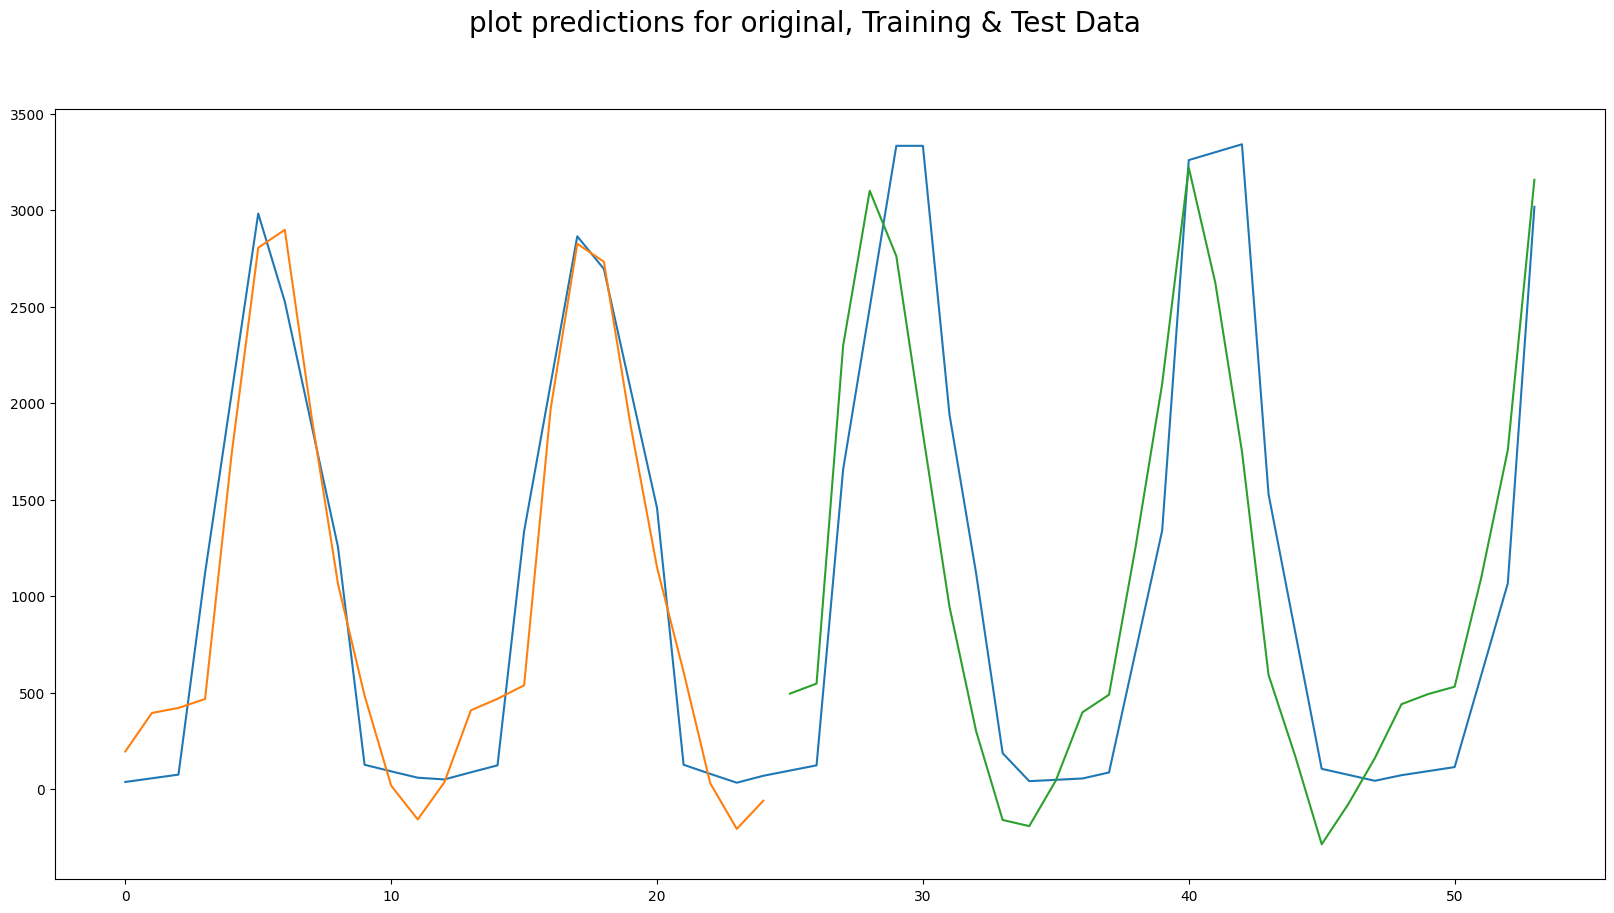

In [12]:
#plot the predictions ???????????????????????????

#total size of plot
total_size = len(predict_on_train) + len(predict_on_test)

#plot original data
orig_data=requests.Requests.to_numpy()
orig_data=orig_data.reshape(len(orig_data),1)

#create a plot for original data
orig_plot = np.empty((total_size,1))
orig_plot[:, :] = np.nan
orig_plot[0:total_size, :] = orig_data[lookback:-2,]

#create a plot for predictions on training
predict_train_plot = np.empty((total_size,1))
predict_train_plot[:, :] = np.nan
predict_train_plot[0:len(predict_on_train), :] = predict_on_train

#create a plot for predictions on testing
predict_test_plot = np.empty((total_size,1))
predict_test_plot[:, :] = np.nan
predict_test_plot[len(predict_on_train):total_size, :] = predict_on_test

#plot the graphs
plt.figure(figsize=(20,10)).suptitle("plot predictions for original, Training & Test Data", fontsize=20)
plt.plot(orig_plot[::1])
plt.plot(predict_train_plot[::1])
plt.plot(predict_test_plot[::1])
plt.show

In [13]:
curr_input= test_req_x[-1, :].flatten()

#predict for the hours
predict_for = 12*2

for i in range(predict_for):
    
    this_input=curr_input[-lookback:]
    this_input=this_input.reshape((1,1,lookback))
    this_prediction=ts_model.predict(this_input)
    
    curr_input = np.append(curr_input,this_prediction.flatten())
predict_on_future=np.reshape(np.array(curr_input[-predict_for:]),(predict_for,1))
predict_on_future=scaler.inverse_transform(predict_on_future)

print(predict_on_future[:5])

1/1 [==============================] - 0s 14ms/step
[[3157.73314366]
 [2748.79752364]
 [1751.62530426]
 [ 676.81362683]
 [ 198.67949879]]


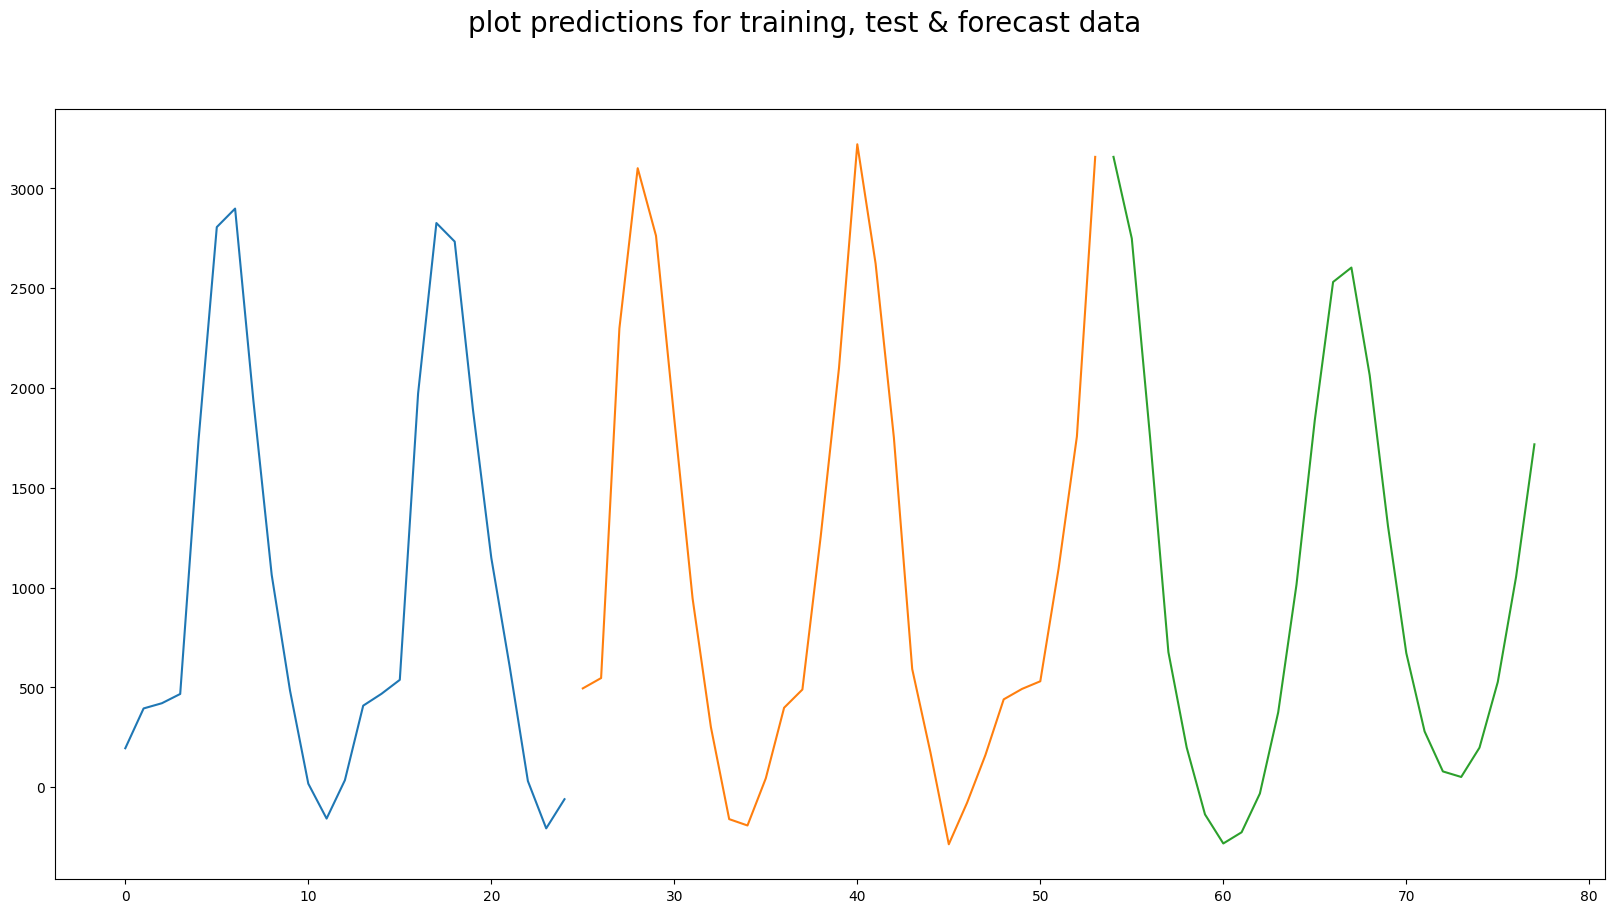

In [14]:
#plot the training data with the forecast data
total_size = len(predict_on_train) + len(predict_on_test) + len(predict_on_future)

#setup training chart
predict_train_plot = np.empty((total_size,1))
predict_train_plot[:, :] = np.nan
predict_train_plot[0:len(predict_on_train), :] = predict_on_train
                        
#setup test chart
predict_test_plot = np.empty((total_size,1))
predict_test_plot[:, :] = np.nan
predict_test_plot[len(predict_on_train):len(predict_on_train)+len(predict_on_test), :] = predict_on_test

#setup future forecast chart
predict_future_plot = np.empty((total_size,1))
predict_future_plot[:, :] = np.nan
predict_future_plot[len(predict_on_train)+len(predict_on_test):total_size, :] = predict_on_future

                         
plt.figure(figsize=(20,10)).suptitle("plot predictions for training, test & forecast data", fontsize=20)
plt.plot(predict_train_plot[::1])
plt.plot(predict_test_plot[::1])
plt.plot(predict_future_plot[::1])
plt.show()

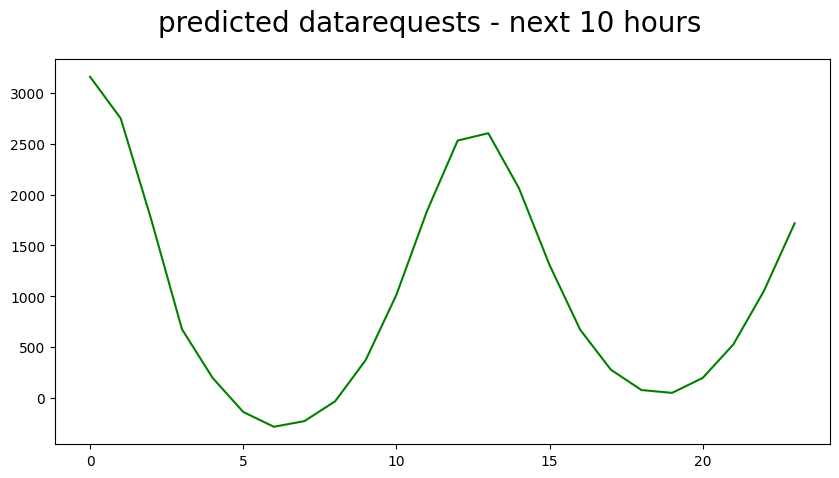

In [15]:
plt.figure(figsize=(10,5)).suptitle("predicted datarequests - next 10 hours", fontsize=20)
plt.plot(predict_on_future,color='g')
plt.show()

In [16]:
from datetime import datetime, timedelta
def daterange(start_date, end_date):
    delta = timedelta(hours=1)
    while start_date < end_date:
        yield start_date
        start_date += delta
        
predicted_dates=[]



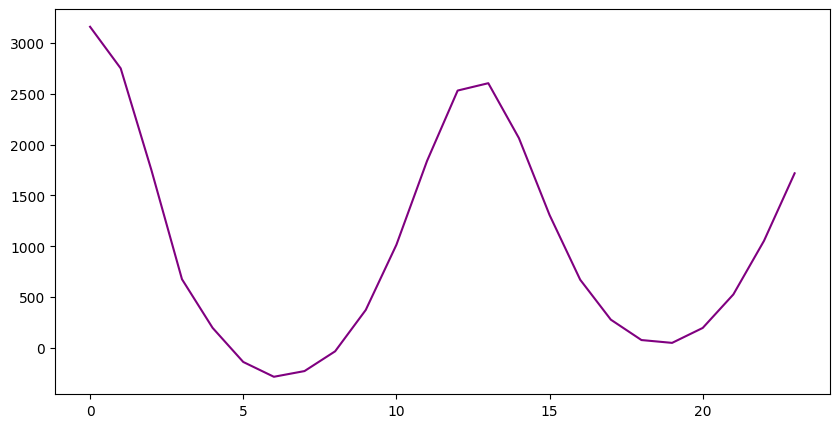

In [17]:

#input dataset enddate upto which dataset is trained and tested and end date isupmost date upto which data is to be predicted - 1year
start_date = datetime(2017,12,31,00,00)
end_date = datetime(2018, 12, 30, 23, 59)
for single_date in daterange(start_date, end_date):
    d=single_date.strftime("%Y-%m-%d %H:%M")
    predicted_dates.append(d)
#print(predicted_dates)

#plotting day data
y_value = predict_on_future[:25]
fig, ax = plt.subplots(figsize=(10,5))

#add x_axis and y_axis
ax.plot(y_value,color='purple')

In [26]:

#set title and labels for axes
ax.set(xlabel="date",
       ylabel="Requests",
       title="predicted next day hourly requests - TCS Server\n ")
day_points=[x for x in range(8760)]
#plt.xticks(day_points,predicted_dates , rotation ='vertical')

#plt.show()

NameError: name 'month_points' is not defined

ValueError: The number of FixedLocator locations (1096), usually from a call to set_ticks, does not match the number of ticklabels (365).

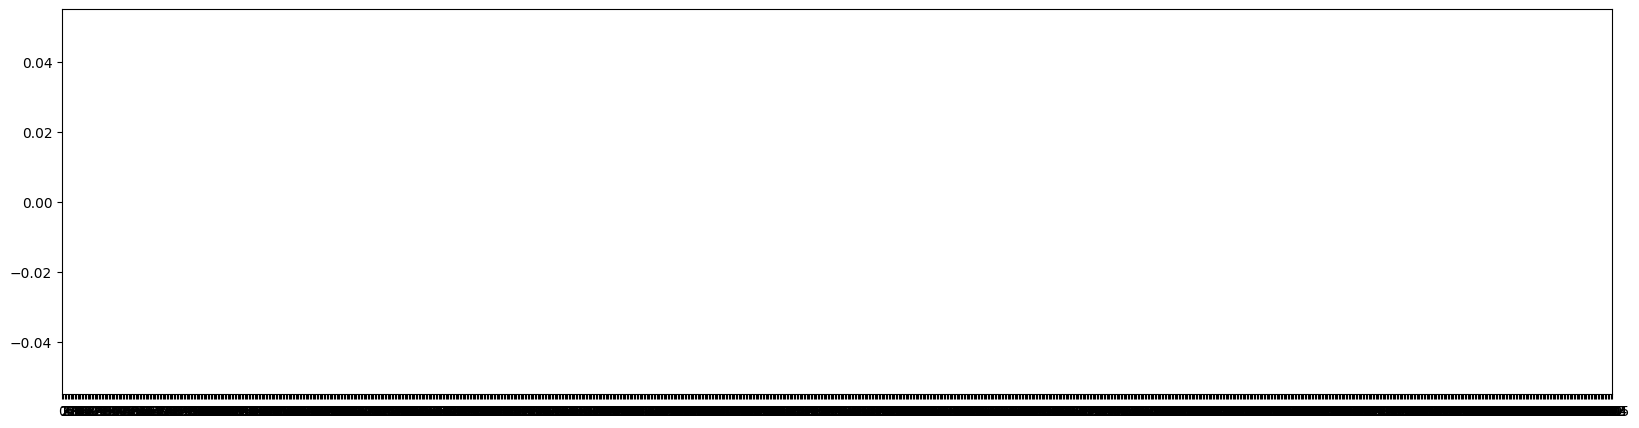

In [27]:
# #plotting weekly data
y_values = predict_on_future[:175]
y_list = [item for sublist in y_values for item in sublist]

total_day_requests=[]
c=0
req_sum=0
for i in range(len(y_list)):
    if c==24:
        c=0
        total_day_requests.append(req_sum)
        req_sum=0
    else:
        req_sum+=y_list[i]
        c+=1
        
#print (total_day_requests)

fig, ax = plt.subplots(figsize=(20, 5))

#add x-axis and y-axis
ax.plot(xlabel="date",
        ylabel="Requests",
        title="predicted next week Requests - TCS Server\n ")

week_dates=[]
for i in range(len(predicted_dates)):
    if i%24==0:
        week_dates.append(predicted_dates[i])
week_points=[x for x in range(1096)]
plt.xticks(week_points, week_dates, rotation ='45')

plt.show()
        